# Models training and tuning

We load the datasets prepared in notebook 2, define the feature set and train Random Forest and XGBoost models.

In [15]:
"""Import training and testing datasets"""
import pandas as pd
from pathlib import Path

TRAINING_PATH = Path("../data/training/tennis_training.xlsx")
TESTING_PATH = Path("../data/testing/tennis_testing.xlsx")

train_df = pd.read_excel(TRAINING_PATH)
test_df = pd.read_excel(TESTING_PATH)


In [16]:
target = "y"

simple_features = [
     "Rank_Diff", "Points_Diff",
    # "Rank_Log_Ratio", "Points_Log_Ratio",
]

odds_features = [
    "Odds_Diff",
    # "Odds_Log_Ratio"
]

player_features = [
    "Age_Diff",
    "Hand_Advantage",
    "Home_Advantage",
]

optimized_features = [
    # "Elo_Diff", 
    "Surface_Elo_Diff",
    # "Recent_Form_Diff", 
    "Recent_Surface_Form_Diff",
    "Fatigue_Diff", 
    "Dominance_Form_Diff",
    # "H2H_Diff", 
    "H2H_Surface_Diff",
]

categorical_features = [
    "Court", 
    "Surface", 
    "Round", 
    # "Tournament", 
    "Series",
]

features_no_odds = simple_features + player_features + optimized_features
features_with_odds = features_no_odds + odds_features

feature_sets = {
    "no_odds": features_no_odds,
    "with_odds": features_with_odds,
}

y_train = train_df[target]

### Why these features?

Incremental comparison using cross-validation on the training set to determine how much each feature group contributes to the model's performance.

Base: 66.03% ± 1.75%
+ Player: 66.23% ± 1.77%
+ Advanced: 68.03% ± 1.40%
+ Categorical: 68.11% ± 1.37%
+ Odds: 69.86% ± 1.47%


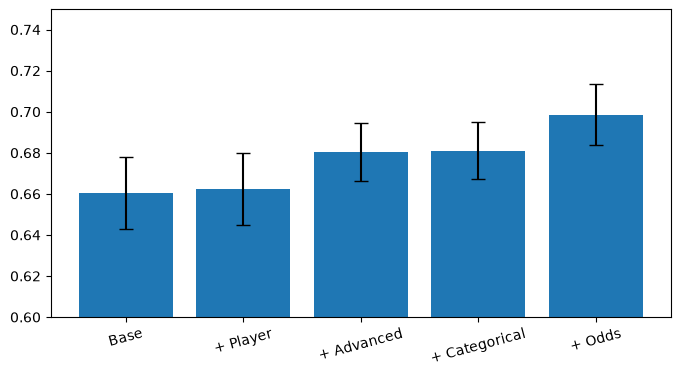

In [17]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

def evaluate_and_plot(stages, df):
    """Evaluate features using TimeSeries CV and plot results."""
    model = make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1))
    cv = TimeSeriesSplit(n_splits=5)
    means, stds = [], []

    for name, feats in stages.items():
        scores = cross_val_score(model, df[feats], df["y"], cv=cv, scoring="accuracy")
        means.append(scores.mean())
        stds.append(scores.std())
        print(f"{name}: {scores.mean():.2%} ± {scores.std():.2%}")

    plt.figure(figsize=(8, 4))
    plt.bar(stages.keys(), means, yerr=stds, capsize=5)
    plt.ylim(0.6, 0.75)
    plt.xticks(rotation=15)
    plt.show()

# --- Execution ---
feature_stages = {
    "Base": simple_features,
    "+ Player": simple_features + player_features,
    "+ Advanced": simple_features + player_features + optimized_features,
    "+ Categorical": features_no_odds,
    "+ Odds": features_with_odds,
}

evaluate_and_plot(feature_stages, train_df)

### Preprocessing pipeline

Same block for both models: median imputation for missing values (with a missing indicator). No scaling: neither Random Forest nor XGBoost need it.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def full_preprocessor(numerical_features, categorical_features):
    
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # group rare or too frequent categories into "other"
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50, max_categories=30)),
    ])
    
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), numerical_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


### Random Forest

Random Forest does not require feature scaling or normalization.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

def train_rf(numerical_features, categorical_features, train_df, y_train):
    preprocessor = full_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])
    param_distributions = {
        "model__n_estimators": randint(150, 400),
        "model__max_depth": randint(3, 10),
        "model__min_samples_leaf": randint(1, 20),
        "model__max_features": ["sqrt", "log2"],
        
        # Test different hyperparams for one hot encoder
        "preprocessor__cat__onehot__min_frequency": randint(20, 100),
        "preprocessor__cat__onehot__max_categories": randint(10, 40),
    }
    
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=100,
        scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
        cv=TimeSeriesSplit(n_splits=5), random_state=42, n_jobs=1, verbose=1, refit="accuracy",
    )
    
    X = train_df[numerical_features + categorical_features]
    search.fit(X, y_train)
    print("Best params:", search.best_params_)
    print("CV accuracy:", f"{search.best_score_:.2%}")
    return search

rf_models = {}
for label, feats in feature_sets.items():
    print(f"--- Random Forest ({label}) ---")
    rf_models[label] = train_rf(feats, categorical_features, train_df, y_train)


--- Random Forest (no_odds) ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 9, 'model__n_estimators': 329, 'preprocessor__cat__onehot__max_categories': 26, 'preprocessor__cat__onehot__min_frequency': 81}
CV accuracy: 68.11%
--- Random Forest (with_odds) ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 9, 'model__n_estimators': 329, 'preprocessor__cat__onehot__max_categories': 26, 'preprocessor__cat__onehot__min_frequency': 81}
CV accuracy: 70.00%


### XGBoost

Same feature set the same validation strategy (`TimeSeriesSplit`) as Random Forest, for a fair comparison.

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, loguniform, uniform

def train_xgb(numerical_features, categorical_features, train_df, y_train):
    preprocessor = full_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
        )),
    ])
    param_distributions = {
        "model__n_estimators": randint(100, 1000),
        "model__learning_rate": loguniform(0.01, 0.2),
        "model__max_depth": randint(1, 7),
        "model__min_child_weight": loguniform(0.5, 10),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__reg_alpha": loguniform(1e-4, 10),
        "model__reg_lambda": loguniform(0.1, 20),
        
        # Test different hyperparams for one hot encoder
        "preprocessor__cat__onehot__min_frequency": randint(50, 200),
        "preprocessor__cat__onehot__max_categories": randint(10, 40),
    }
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=1000,
        scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
        cv=TimeSeriesSplit(n_splits=5), random_state=42, n_jobs=-1, verbose=1, refit="accuracy",
    )
    X = train_df[numerical_features + categorical_features]
    search.fit(X, y_train)
    print("Best params:", search.best_params_)
    print("CV accuracy:", f"{search.best_score_:.2%}")
    return search

xgb_models = {}
for label, feats in feature_sets.items():
    print(f"--- XGBoost ({label}) ---")
    xgb_models[label] = train_xgb(feats, categorical_features, train_df, y_train)


--- XGBoost (no_odds) ---
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Best params: {'model__colsample_bytree': np.float64(0.8861289242116542), 'model__learning_rate': np.float64(0.02232864581645069), 'model__max_depth': 5, 'model__min_child_weight': np.float64(0.7276551593188436), 'model__n_estimators': 222, 'model__reg_alpha': np.float64(0.00032557120815233866), 'model__reg_lambda': np.float64(0.10651815522061603), 'model__subsample': np.float64(0.6558769490411754), 'preprocessor__cat__onehot__max_categories': 24, 'preprocessor__cat__onehot__min_frequency': 144}
CV accuracy: 68.46%
--- XGBoost (with_odds) ---
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Best params: {'model__colsample_bytree': np.float64(0.920852223251035), 'model__learning_rate': np.float64(0.013711542756108074), 'model__max_depth': 1, 'model__min_child_weight': np.float64(8.778231187117356), 'model__n_estimators': 376, 'model__reg_alpha': np.float64(0.008669142812188408), 'mo

### Saving the models

In [21]:
import pickle
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)
for label, search in {**{f"rf_{k}": v for k,v in rf_models.items()}, **{f"xgb_{k}": v for k,v in xgb_models.items()}}.items():
    with open(f"../models/{label}_model.pkl", "wb") as f:
        pickle.dump(search.best_estimator_, f)
    print(f"Saved {label}_model.pkl")


Saved rf_no_odds_model.pkl
Saved rf_with_odds_model.pkl
Saved xgb_no_odds_model.pkl
Saved xgb_with_odds_model.pkl
